In [1]:
import csv
import unittest
from datetime import date

import pandas as pd
import numpy as np

import trachoma.trachoma_functions as tf
import multiprocessing
import time
from joblib import Parallel, delayed
num_cores = multiprocessing.cpu_count()
import pickle

class EndToEndTest(unittest.TestCase):
    """
    This is an end-to-end test for trachoma_functions.py run_single_simulation.

    The results of the simulation are compared to the reference results
    reference_output/outsIHME2c.csv and reference_output/outsIPM2c.csv
    The reference files are simply the output of this file with seed=0.

    If the tests are failing and you know the code is correct, run only test_seed_0 and
    copy the outputs in the tests folder to the reference_output folder.
    """

    def test_seed_0(self):
        """
        The references files were created with seed=0. This test shows
        that with the seed=0, the outputs of the simulation are the same as
        the reference files.
        """
        self.run_simulation(0)
        with open('tests/reference_output/endtoendIPMOuts.csv', newline='') as expected_IPM_file:
            expected_IPM_data = list(csv.reader(expected_IPM_file))
        with open('endtoendIPMOuts.csv', newline='') as actual_IPM_file:
            actual_IPM_data = list(csv.reader(actual_IPM_file))
        self.assertListEqual(expected_IPM_data, actual_IPM_data)
        with open('tests/reference_output/endtoendIHMEOuts.csv', newline='') as expected_IHME_file:
            expected_IHME_data = list(csv.reader(expected_IHME_file))
        with open('endtoendIHMEOuts.csv', newline='') as actual_IHME_file:
            actual_IHME_data = list(csv.reader(actual_IHME_file))
        self.assertListEqual(expected_IHME_data, actual_IHME_data)

    def test_seed_not_0(self):
        """
        The references files were created with seed=0. This test shows
        that with the seed=123456, the outputs of the simulation are different
        than the reference files.
        """
        self.run_simulation(12345)
        with open('reference_output/endtoendIPMOuts.csv', newline='') as expected_IPM_file:
            expected_IPM_data = list(csv.reader(expected_IPM_file))
        with open('endtoendIPMOuts.csv', newline='') as actual_IPM_file:
            actual_IPM_data = list(csv.reader(actual_IPM_file))
        self.assertNotEqual(expected_IPM_data, actual_IPM_data)
        with open('reference_output/endtoendIHMEOuts.csv', newline='') as expected_IHME_file:
            expected_IHME_data = list(csv.reader(expected_IHME_file))
        with open('endtoendIHMEOuts.csv', newline='') as actual_IHME_file:
            actual_IHME_data = list(csv.reader(actual_IHME_file))
        self.assertNotEqual(expected_IHME_data, actual_IHME_data)

    @staticmethod
    def run_simulation(seed):
        """
        Runs the simulation with a particular seed. A helper function for the tests.
        """

        #############################################################################################################################
        #############################################################################################################################

        # decide how many sims we will run
        numSims = 1

        # we set the seed for generating the numpy states below, leave seed=None for random data, or a value like seed=0 for consistent run-to-run data
        np.random.seed(seed)
        # we generate a numpy state for each simulation by saving a state. If the seed is set above, this will be consistent from run to run
        numpy_states = list(map(lambda s: tf.seed_to_state(s), np.random.randint(2^32, size=numSims)))

        # initialize parameters, sim_params, and demography

        params = {'N': 2500,
                  'av_I_duration' : 2,
                  'av_ID_duration':200/7,
                  'inf_red':0.45,
                  'min_ID':11, #Parameters relating to duration of infection period, including ID period
                  'av_D_duration':300/7,
                  'min_D':1, #Parameters relating to duration of disease period
                  'v_1':1,
                  'v_2':2.6,
                  'phi':1.4,
                  'epsilon':0.5,#Parameters relating to lambda function- calculating force of infection
                  #Parameters relating to MDA
                  'MDA_Cov':0.8,
                  'MDA_Eff': 0.85, # Efficacy of treatment
                  'rho':0.3,
                  'nweeks_year':52,
                  'babiesMaxAge':0.5, #Note this is years, need to check it converts to weeks later
                  'youngChildMaxAge':9,#Note this is years, need to check it converts to weeks later
                  'olderChildMaxAge':15, #Note this is years, need to check it converts to weeks later
                  'b1':1,#this relates to bacterial load function
                  'ep2':0.114,
                  'n_inf_sev':38,
                  'TestSensitivity': 0.96,
                  'TestSpecificity': 0.965,
                  'SecularTrendIndicator': 0,
                  'SecularTrendYearlyBetaDecrease': 0.05,
                  'vacc_prob_block_transmission':  0.8,
                  'vacc_reduce_bacterial_load': 0.5,
                  'vacc_reduce_duration': 0.5,
                  'vacc_waning_length': 52 * 5}


        sim_params = {'timesim':52*23,
                      'burnin': 26,
                      'N_MDA':5,
                      'nsim':10}


        demog = {'tau': 0.0004807692,
                 'max_age': 3120,
                 'mean_age': 1040}



        previous_rounds = 0


        Start_date = date(2019,1, 1)
        End_date = date(2029,12,31)
        #############################################################################################################################
        #############################################################################################################################
        # import pickle file and beta values.
        # path to pickle file
        PickleFilePath = 'results/endtoendpicklefile.p'
        # load pickle file
        with open(PickleFilePath, 'rb') as pickleFile:
            pickleData =  pickle.load(pickleFile)
        # load beta file
        BetaFilePath = 'data/endtoend_betavalues.csv'
        # read in parameters
        allBetas = pd.read_csv(BetaFilePath)
        #############################################################################################################################
        #############################################################################################################################
        # make sure the N parameter is the same as the number of people in the pickle file
        params['N'] = len(pickleData[0]['IndI'])
        #############################################################################################################################
        #############################################################################################################################
        # which years to make endgame output specify and convert these to simulation time
        outputYear = range(Start_date.year, End_date.year)
        outputTimes = tf.getOutputTimes(outputYear)
        outputTimes = tf.get_Intervention_times(outputTimes, Start_date, sim_params['burnin'])


        #############################################################################################################################
        #############################################################################################################################

        # generate MDA data from coverage file
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        scenario = '2c'
        coverageFileName = 'scen' + scenario + '.csv'
        MDAData = tf.readPlatformData(coverageFileName, "MDA")
        MDA_dates = tf.getInterventionDates(MDAData)
        MDA_times = tf.get_Intervention_times(MDA_dates, Start_date, sim_params['burnin'])
        sim_params['N_MDA'] = len(MDA_times)
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        VaccData = tf.readPlatformData(coverageFileName, "Vaccine")
        Vaccine_dates = tf.getInterventionDates(VaccData)
        vacc_times = tf.get_Intervention_times(Vaccine_dates, Start_date, sim_params['burnin'])
        sim_params['N_Vaccines'] = len(vacc_times)
        #############################################################################################################################
        #############################################################################################################################

        print( f'Running {numSims} simulations on {num_cores} cores' )
        start = time.time()

        #############################################################################################################################
        #############################################################################################################################
        # run as many simulations as specified
        results = Parallel(n_jobs=num_cores)(
                 delayed(tf.run_single_simulation)(pickleData = pickleData[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                params = params,
                                                timesim = sim_params['timesim'],
                                                burnin = sim_params['burnin'],
                                                demog=demog,
                                                beta = allBetas.beta[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                MDA_times = MDA_times,
                                                MDAData=MDAData,
                                                vacc_times = vacc_times,
                                                VaccData = VaccData,
                                                outputTimes= outputTimes,
                                                index = i,
                                                # We use a fresh state for each simulation
                                                numpy_state=numpy_states[i]) for i in range(numSims))


        print(time.time()- start)
        #############################################################################################################################
        #############################################################################################################################
        # collate and output IHME data

        outsIHME = tf.getResultsIHME(results, demog, params, outputYear)
        outsIHME.to_csv('endtoendIHMEOuts.csv',index=False)



        #############################################################################################################################
        #############################################################################################################################
        # collate and output IPM data
        MDAAgeRanges = tf.getInterventionAgeRanges(coverageFileName, "MDA")
        VaccAgeRanges = tf.getInterventionAgeRanges(coverageFileName, "Vaccine")
        outsIPM = tf.getResultsIPM(results, demog, params, outputYear, MDAAgeRanges, VaccAgeRanges)
        outsIPM.to_csv('endtoendIPMOuts.csv',index=False)

In [2]:
def seed_to_state(seed):
        np.random.seed(seed)
        return np.random.get_state()

def run_simulation(seed):
        """
        Runs the simulation with a particular seed. A helper function for the tests.
        """

        #############################################################################################################################
        #############################################################################################################################

        # decide how many sims we will run
        numSims = 1

        # we set the seed for generating the numpy states below, leave seed=None for random data, or a value like seed=0 for consistent run-to-run data
        np.random.seed(seed)
        # we generate a numpy state for each simulation by saving a state. If the seed is set above, this will be consistent from run to run
        numpy_states = list(map(lambda s: tf.seed_to_state(s), np.random.randint(2^32, size=numSims)))

        # initialize parameters, sim_params, and demography

        params = {'N': 2500,
                  'av_I_duration' : 2,
                  'av_ID_duration':200/7,
                  'inf_red':0.45,
                  'min_ID':11, #Parameters relating to duration of infection period, including ID period
                  'av_D_duration':300/7,
                  'min_D':1, #Parameters relating to duration of disease period
                  'v_1':1,
                  'v_2':2.6,
                  'phi':1.4,
                  'epsilon':0.5,#Parameters relating to lambda function- calculating force of infection
                  #Parameters relating to MDA
                  'MDA_Cov':0.8,
                  'MDA_Eff': 0.85, # Efficacy of treatment
                  'rho':0.3,
                  'nweeks_year':52,
                  'babiesMaxAge':0.5, #Note this is years, need to check it converts to weeks later
                  'youngChildMaxAge':9,#Note this is years, need to check it converts to weeks later
                  'olderChildMaxAge':15, #Note this is years, need to check it converts to weeks later
                  'b1':1,#this relates to bacterial load function
                  'ep2':0.114,
                  'n_inf_sev':38,
                  'TestSensitivity': 0.96,
                  'TestSpecificity': 0.965,
                  'SecularTrendIndicator': 0,
                  'SecularTrendYearlyBetaDecrease': 0.05,
                  'vacc_prob_block_transmission':  0.8,
                  'vacc_reduce_bacterial_load': 0.5,
                  'vacc_reduce_duration': 0.5,
                  'vacc_waning_length': 52 * 5}


        sim_params = {'timesim':52*23,
                      'burnin': 26,
                      'N_MDA':5,
                      'nsim':10}


        demog = {'tau': 0.0004807692,
                 'max_age': 3120,
                 'mean_age': 1040}



        previous_rounds = 0


        Start_date = date(2019,1, 1)
        End_date = date(2029,12,31)
        #############################################################################################################################
        #############################################################################################################################
        # import pickle file and beta values.
        # path to pickle file
        PickleFilePath = 'endtoendpicklefile.p'
        # load pickle file
        with open(PickleFilePath, 'rb') as pickleFile:
            pickleData =  pickle.load(pickleFile)
        # load beta file
        BetaFilePath = 'endtoend_betavalues.csv'
        # read in parameters
        allBetas = pd.read_csv(BetaFilePath)
        #############################################################################################################################
        #############################################################################################################################
        # make sure the N parameter is the same as the number of people in the pickle file
        params['N'] = len(pickleData[0]['IndI'])
        #############################################################################################################################
        #############################################################################################################################
        # which years to make endgame output specify and convert these to simulation time
        outputYear = range(Start_date.year, End_date.year)
        outputTimes = tf.getOutputTimes(outputYear)
        outputTimes = tf.get_Intervention_times(outputTimes, Start_date, sim_params['burnin'])


        #############################################################################################################################
        #############################################################################################################################

        # generate MDA data from coverage file
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        scenario = '2c'
        coverageFileName = 'scen' + scenario + '.csv'
        MDAData = tf.readPlatformData(coverageFileName, "MDA")
        MDA_dates = tf.getInterventionDates(MDAData)
        MDA_times = tf.get_Intervention_times(MDA_dates, Start_date, sim_params['burnin'])
        sim_params['N_MDA'] = len(MDA_times)
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        VaccData = tf.readPlatformData(coverageFileName, "Vaccine")
        Vaccine_dates = tf.getInterventionDates(VaccData)
        vacc_times = tf.get_Intervention_times(Vaccine_dates, Start_date, sim_params['burnin'])
        sim_params['N_Vaccines'] = len(vacc_times)
        #############################################################################################################################
        #############################################################################################################################

        print( f'Running {numSims} simulations on {num_cores} cores' )
        start = time.time()

        #############################################################################################################################
        #############################################################################################################################
        # run as many simulations as specified
        results = Parallel(n_jobs=num_cores)(
                 delayed(tf.run_single_simulation)(pickleData = pickleData[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                params = params,
                                                timesim = sim_params['timesim'],
                                                burnin = sim_params['burnin'],
                                                demog=demog,
                                                beta = allBetas.beta[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                MDA_times = MDA_times,
                                                MDAData=MDAData,
                                                vacc_times = vacc_times,
                                                VaccData = VaccData,
                                                outputTimes= outputTimes,
                                                index = i,
                                                # We use a fresh state for each simulation
                                                numpy_state=numpy_states[i]) for i in range(numSims))


        print(time.time()- start)
        #############################################################################################################################
        #############################################################################################################################
        # collate and output IHME data

        outsIHME = tf.getResultsIHME(results, demog, params, outputYear)
        outsIHME.to_csv('endtoendIHMEOuts.csv',index=False)



        #############################################################################################################################
        #############################################################################################################################
        # collate and output IPM data
        MDAAgeRanges = tf.getInterventionAgeRanges(coverageFileName, "MDA")
        VaccAgeRanges = tf.getInterventionAgeRanges(coverageFileName, "Vaccine")
        outsIPM = tf.getResultsIPM(results, demog, params, outputYear, MDAAgeRanges, VaccAgeRanges)
        outsIPM.to_csv('endtoendIPMOuts.csv',index=False)

In [3]:
run_simulation(0)

Running 1 simulations on 8 cores
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyPass = 1
Doing MDA
surveyP

/Users/matthewgraham/Dropbox/Github/ntd-model-trachoma/trachoma/trachoma_functions.py:1001: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalence' 'TruePrevalence' 'TruePrevalence'
 'TruePrevalence' 'TruePrevalen

In [4]:
with open('tests/reference_output/endtoendIPMOuts.csv', newline='') as expected_IPM_file:
            expected_IPM_data = list(csv.reader(expected_IPM_file))
expected_IPM_data

[['Time', 'age_start', 'age_end', 'measure', 'draw_0'],
 ['2019', 'None', 'None', 'nSurvey', '0.0'],
 ['2019', 'None', 'None', 'surveyPass', '1.0'],
 ['2019', 'None', 'None', 'trueElimination', '1.0'],
 ['2019', '0', '100', 'nDosesMDA', '0.0'],
 ['2019', '0', '100', 'MDAcoverage', '0.0'],
 ['2019', '0', '100', 'numMDAs', '0.0'],
 ['2019', '1', '10', 'nDosesMDA', '0.0'],
 ['2019', '1', '10', 'MDAcoverage', '0.0'],
 ['2019', '1', '10', 'numMDAs', '0.0'],
 ['2020', 'None', 'None', 'nSurvey', '0.0'],
 ['2020', 'None', 'None', 'surveyPass', '1.0'],
 ['2020', 'None', 'None', 'trueElimination', '1.0'],
 ['2020', '0', '100', 'nDosesMDA', '0.0'],
 ['2020', '0', '100', 'MDAcoverage', '0.0'],
 ['2020', '0', '100', 'numMDAs', '0.0'],
 ['2020', '1', '10', 'nDosesMDA', '0.0'],
 ['2020', '1', '10', 'MDAcoverage', '0.0'],
 ['2020', '1', '10', 'numMDAs', '0.0'],
 ['2021', 'None', 'None', 'nSurvey', '0.0'],
 ['2021', 'None', 'None', 'surveyPass', '1.0'],
 ['2021', 'None', 'None', 'trueElimination', '1.0

In [5]:
with open('endtoendIPMOuts.csv', newline='') as actual_IPM_file:
            actual_IPM_data = list(csv.reader(actual_IPM_file))
actual_IPM_data

[['Time', 'age_start', 'age_end', 'measure', 'draw_0'],
 ['2019', 'None', 'None', 'nSurvey', '0'],
 ['2019', 'None', 'None', 'surveyPass', '1'],
 ['2019', 'None', 'None', 'trueElimination', '1'],
 ['2019', '0', '100', 'nDosesMDA', '0'],
 ['2019', '0', '100', 'MDAcoverage', '0'],
 ['2019', '0', '100', 'numMDAs', '0'],
 ['2019', '1', '10', 'nDosesMDA', '0'],
 ['2019', '1', '10', 'MDAcoverage', '0'],
 ['2019', '1', '10', 'numMDAs', '0'],
 ['2020', 'None', 'None', 'nSurvey', '0'],
 ['2020', 'None', 'None', 'surveyPass', '1'],
 ['2020', 'None', 'None', 'trueElimination', '1'],
 ['2020', '0', '100', 'nDosesMDA', '0'],
 ['2020', '0', '100', 'MDAcoverage', '0'],
 ['2020', '0', '100', 'numMDAs', '0'],
 ['2020', '1', '10', 'nDosesMDA', '0'],
 ['2020', '1', '10', 'MDAcoverage', '0'],
 ['2020', '1', '10', 'numMDAs', '0'],
 ['2021', 'None', 'None', 'nSurvey', '0'],
 ['2021', 'None', 'None', 'surveyPass', '1'],
 ['2021', 'None', 'None', 'trueElimination', '1'],
 ['2021', '0', '100', 'nDosesMDA', '0'

In [1]:
        """
        Runs the simulation with a particular seed. A helper function for the tests.
        """
        seed = 0

        #############################################################################################################################
        #############################################################################################################################

        # decide how many sims we will run
        numSims = 1

        # we set the seed for generating the numpy states below, leave seed=None for random data, or a value like seed=0 for consistent run-to-run data
        np.random.seed(seed)
        # we generate a numpy state for each simulation by saving a state. If the seed is set above, this will be consistent from run to run
        numpy_states = list(map(lambda s: tf.seed_to_state(s), np.random.randint(2^32, size=numSims)))

        # initialize parameters, sim_params, and demography

        params = {'N': 2500,
                  'av_I_duration' : 2,
                  'av_ID_duration':200/7,
                  'inf_red':0.45,
                  'min_ID':11, #Parameters relating to duration of infection period, including ID period
                  'av_D_duration':300/7,
                  'min_D':1, #Parameters relating to duration of disease period
                  'v_1':1,
                  'v_2':2.6,
                  'phi':1.4,
                  'epsilon':0.5,#Parameters relating to lambda function- calculating force of infection
                  #Parameters relating to MDA
                  'MDA_Cov':0.8,
                  'MDA_Eff': 0.85, # Efficacy of treatment
                  'rho':0.3,
                  'nweeks_year':52,
                  'babiesMaxAge':0.5, #Note this is years, need to check it converts to weeks later
                  'youngChildMaxAge':9,#Note this is years, need to check it converts to weeks later
                  'olderChildMaxAge':15, #Note this is years, need to check it converts to weeks later
                  'b1':1,#this relates to bacterial load function
                  'ep2':0.114,
                  'n_inf_sev':38,
                  'TestSensitivity': 0.96,
                  'TestSpecificity': 0.965,
                  'SecularTrendIndicator': 0,
                  'SecularTrendYearlyBetaDecrease': 0.05,
                  'vacc_prob_block_transmission':  0.8,
                  'vacc_reduce_bacterial_load': 0.5,
                  'vacc_reduce_duration': 0.5,
                  'vacc_waning_length': 52 * 5}


        sim_params = {'timesim':52*23,
                      'burnin': 26,
                      'N_MDA':5,
                      'nsim':10}


        demog = {'tau': 0.0004807692,
                 'max_age': 3120,
                 'mean_age': 1040}



        previous_rounds = 0


        Start_date = date(2019,1, 1)
        #############################################################################################################################
        #############################################################################################################################
        # import pickle file and beta values.
        # path to pickle file
        PickleFilePath = 'endtoendpicklefile.p'
        # load pickle file
        with open(PickleFilePath, 'rb') as pickleFile:
            pickleData =  pickle.load(pickleFile)
        # load beta file
        BetaFilePath = 'endtoend_betavalues.csv'
        # read in parameters
        allBetas = pd.read_csv(BetaFilePath)
        #############################################################################################################################
        #############################################################################################################################
        # make sure the N parameter is the same as the number of people in the pickle file
        params['N'] = len(pickleData[0]['IndI'])
        #############################################################################################################################
        #############################################################################################################################
        # which years to make endgame output specify and convert these to simulation time
        outputYear = range(Start_date.year, End_date.year)
        outputTimes = tf.getOutputTimes(outputYear)
        outputTimes = tf.get_Intervention_times(outputTimes, Start_date, sim_params['burnin'])


        #############################################################################################################################
        #############################################################################################################################

        # generate MDA data from coverage file
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        scenario = '2c'
        coverageFileName = 'scen' + scenario + '.csv'
        MDAData = tf.readPlatformData(coverageFileName, "MDA")
        MDA_dates = tf.getInterventionDates(MDAData)
        MDA_times = tf.get_Intervention_times(MDA_dates, Start_date, sim_params['burnin'])
        sim_params['N_MDA'] = len(MDA_times)
        # this is currently using something outside of the test folder which is bad
        # but readPlatformData is hardcoded for this
        VaccData = tf.readPlatformData(coverageFileName, "Vaccine")
        Vaccine_dates = tf.getInterventionDates(VaccData)
        vacc_times = tf.get_Intervention_times(Vaccine_dates, Start_date, sim_params['burnin'])
        sim_params['N_Vaccines'] = len(vacc_times)
        #############################################################################################################################
        #############################################################################################################################

        print( f'Running {numSims} simulations on {num_cores} cores' )
        start = time.time()

        #############################################################################################################################
        #############################################################################################################################
        # run as many simulations as specified
        results = Parallel(n_jobs=num_cores)(
                 delayed(tf.run_single_simulation)(pickleData = pickleData[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                params = params,
                                                timesim = sim_params['timesim'],
                                                burnin = sim_params['burnin'],
                                                demog=demog,
                                                beta = allBetas.beta[0], # there is only a single entry in test data, so is set as zero in case we need more simulations
                                                MDA_times = MDA_times,
                                                MDAData=MDAData,
                                                vacc_times = vacc_times,
                                                VaccData = VaccData,
                                                outputTimes= outputTimes,
                                                index = i,
                                                # We use a fresh state for each simulation
                                                numpy_state=numpy_states[i]) for i in range(numSims))


NameError: name 'np' is not defined

In [21]:
MDAData

[[2020.0, 0, 100, 0.8, 0, 2],
 [2021.0, 0, 100, 0.8, 0, 2],
 [2022.0, 0, 100, 0.8, 0, 2],
 [2023.0, 0, 100, 0.8, 0, 2],
 [2024.0, 0, 100, 0.85, 0, 2],
 [2024.083333, 1, 10, 0.85, 1, 2],
 [2024.166667, 1, 10, 0.85, 1, 2],
 [2025.0, 0, 100, 0.85, 0, 2],
 [2025.083333, 1, 10, 0.85, 1, 2],
 [2025.166667, 1, 10, 0.85, 1, 2],
 [2026.0, 0, 100, 0.85, 0, 2],
 [2026.083333, 1, 10, 0.85, 1, 2],
 [2026.166667, 1, 10, 0.85, 1, 2],
 [2027.0, 0, 100, 0.85, 0, 2],
 [2027.083333, 1, 10, 0.85, 1, 2],
 [2027.166667, 1, 10, 0.85, 1, 2],
 [2028.0, 0, 100, 0.85, 0, 2],
 [2028.083333, 1, 10, 0.85, 1, 2],
 [2028.166667, 1, 10, 0.85, 1, 2],
 [2029.0, 0, 100, 0.85, 0, 2],
 [2029.083333, 1, 10, 0.85, 1, 2],
 [2029.166667, 1, 10, 0.85, 1, 2],
 [2030.0, 0, 100, 0.85, 0, 2],
 [2030.083333, 1, 10, 0.85, 1, 2],
 [2030.166667, 1, 10, 0.85, 1, 2],
 [2031.0, 0, 100, 0.85, 0, 2],
 [2031.083333, 1, 10, 0.85, 1, 2],
 [2031.166667, 1, 10, 0.85, 1, 2],
 [2032.0, 0, 100, 0.85, 0, 2],
 [2032.083333, 1, 10, 0.85, 1, 2],
 [2032

In [20]:
sum(pickleData[0]['IndI'])


0.0

In [42]:
vacc_times = []
seed = 10
beta = 0.17

In [43]:



MDAData1, MDA_times1 = get_MDA_data("scen1_no_interruption.csv")
data1 = SimulationFunction(params, sim_params, demog, MDA_times1, MDAData1, vacc_times, VaccData, outputTimes, seed_bump  = seed, beta = beta)
res1 = analyseResults(data1, sim_params)

MDAData2, MDA_times2 = get_MDA_data("scen1_interrupt_no_mitigation.csv")

data2 = SimulationFunction(params, sim_params, demog, MDA_times2, MDAData2, vacc_times, VaccData, outputTimes, seed_bump  = seed, beta = beta)
res2 = analyseResults(data2, sim_params)

MDAData3, MDA_times3 = get_MDA_data("scen1_interrupt_mitigation.csv")
data3 = SimulationFunction(params, sim_params, demog, MDA_times3, MDAData3, vacc_times, VaccData, outputTimes, seed_bump  = seed, beta = beta)
res3 = analyseResults(data3, sim_params)

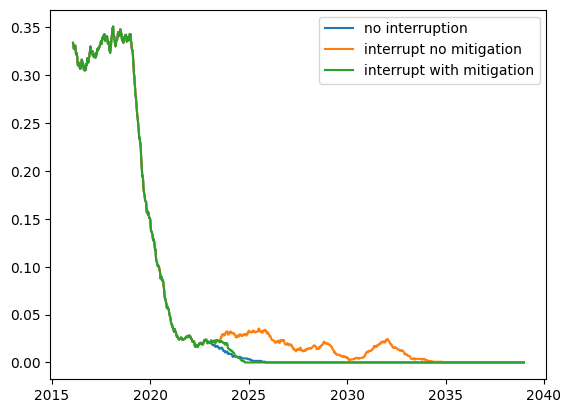

In [44]:
import matplotlib.pyplot as plt
start_year = 2018-burnin/52
plt.plot(start_year + res1[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res1[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res2[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res2[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res3[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res3[0]['Median_Disease_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 

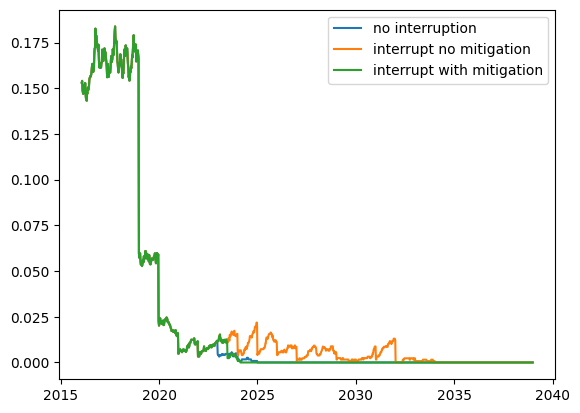

In [45]:
import matplotlib.pyplot as plt
start_year = 2018-burnin/52
plt.plot(start_year + res1[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res1[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res2[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res2[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.plot(start_year + res3[0]['Time'][(sim_params['burnin']-100): sim_params['timesim']],res3[0]['Median_Infection_Children'][(sim_params['burnin']-100): sim_params['timesim']])
plt.legend(['no interruption', 'interrupt no mitigation', 'interrupt with mitigation']) 